# Import Packages

In [1]:
import sys
print(sys.executable)

c:\Users\xin37\github\CNN-LSTM-model-for-energy-usage-forecasting-1\venv\Scripts\python.exe


In [2]:
# univariate multi-step lstm for the power usage dataset

import time

# Start counting notebook running time
time_start = time.time()

import numpy as np
import tensorflow as tf
# Set all random seeds for the program (Python, NumPy, and TensorFlow)
tf.keras.utils.set_random_seed(1)

import pandas as pd
from  IPython.display import display, Image
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM, RepeatVector, TimeDistributed
from keras.layers import Conv1D, MaxPooling1D
from keras.utils import plot_model
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import sklearn
import keras
import pandas as pd
from time import strftime
current_time = strftime("%Y-%m-%d-%H-%M-%S")
print('current time: ', current_time)
print('numpy version: ', np.__version__)
print('tensorflow version: ', tf.__version__)
print('pandas version: ', pd.__version__)
print('scikit-learn version: ', sklearn.__version__)
print('keras version: ', keras.__version__)

current time:  2026-04-13-02-32-53
numpy version:  2.4.4
tensorflow version:  2.21.0
pandas version:  3.0.2
scikit-learn version:  1.8.0
keras version:  3.14.0


# Import Data¶
## Daily power data of all campus buildings of IIT Delhi

In [4]:
%%time
path ='C:\\Users\\xin37\\github\\CNN-LSTM-model-for-energy-usage-forecasting-1\\data\\cold_source_control_dataset.csv'
data = pd.read_csv(
    path,
    header=0, 
    parse_dates=['Timestamp'], 
    index_col=['Timestamp']
)
print(data.shape)
display(data.head())

(3498, 11)


,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action,Output
Timestamp,,,,,,,,,,,
2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,Reduce AHU,1
2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,Eco Mode,4
2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,Eco Mode,4
2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,Boost All,3
2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,Eco Mode,4


CPU times: total: 15.6 ms
Wall time: 70.6 ms


# Visualize sample data

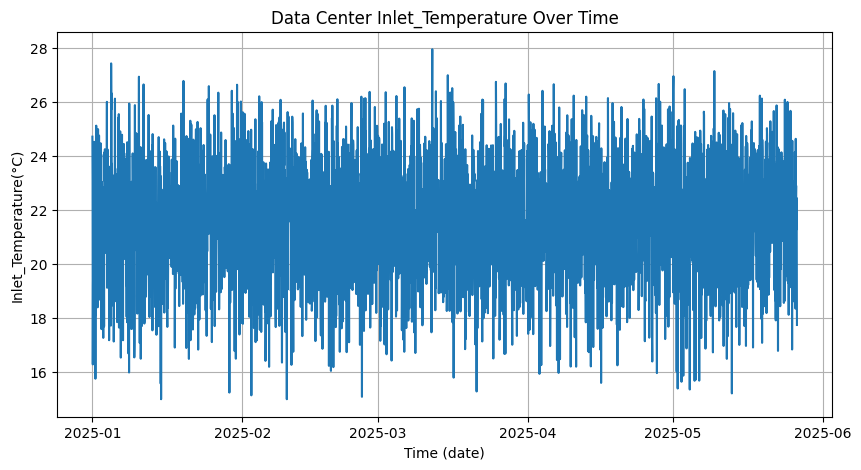

CPU times: total: 156 ms
Wall time: 322 ms


In [5]:
%%time
fig = plt.figure(figsize=(10, 5));
plt.plot(data.index, data['Inlet_Temperature(°C)']) 

plt.xlabel('Time (date)')
plt.ylabel('Inlet_Temperature(°C)')
plt.title('Data Center Inlet_Temperature Over Time')
plt.grid(True) # Added for better readability
plt.show()

# Split a dataset into train/test sets

In [6]:
n_input = 24   # past 24 hours
n_output = 1   # predict next 1 hour
test_size = 24 * 7  # last 1 week for testing

# data = data.sort_index()

# # optional time features
# data['hour'] = data.index.hour
# data['day_of_week'] = data.index.dayofweek

def split_dataset(data, n_input, n_output, test_size_hours):
    # select features and target
    feature_cols = [
        'Server_Workload(%)',
        'Ambient_Temperature(°C)',
        'Cooling_Unit_Power_Consumption(kW)',
        'Chiller_Usage(%)',
        'AHU_Usage(%)'
    ]

    X = data[feature_cols]
    y = data['Inlet_Temperature(°C)']

    # split index
    split_point = len(data) - test_size_hours

    X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
    y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

    return X_train.values, y_train.values, X_test.values, y_test.values
# # number of weeks in training data
# nwt = 200

# # Number of weeks in test data (predictions will be made and compared)
# nwp = 12

# split dataset into train and test sets
# def split_dataset(data, n_output):
#     # slice dataset as multiples of output sequence
#     data = data.tail(n_output*nwt) #
#     # split into train and test set
#     train = np.array(data.iloc[:-n_output*nwp])
#     test =  np.array(data.iloc[-n_output*nwp:-n_output] )
#     return train, test

In [7]:
result = split_dataset(data, n_input, n_output, test_size)
print(type(result))
print(len(result))

<class 'tuple'>
4


#  Format the data in the overlapping moving window format¶
We need to restrucutre the time-series data in order for training and making predictions like a supervised machine learning model. For every n_input sequence of data, the n_ouput sequence will be target values. We will also increment the sequences by 1 each time to utilise the so called overlapping window format.

In [8]:
# convert data into input and output steps
def transform_data(train, n_input, n_output):
    X, y = [], []
    # loop over the data by 1 time step
    for i in range(len(train)):
        # define the index range of the input
        in_end = i + n_input
        out_end = in_end + n_output
        if out_end <= len(train):
            # x_input = train[i:in_end, 0] # only one feature/column is selected
            x_input = train[i:in_end, :]   # ✔️ use ALL features
            # x_input = x_input.reshape((len(x_input), 1))  only single feature/column is selected
            X.append(x_input)
            y.append(train[in_end:out_end, 0])
    return np.array(X), np.array(y)

# The function returns two NumPy arrays:
# $X$: A 3D array of shape (number_of_samples, n_input, 1).
# $y$: A 2D array of shape (number_of_samples, n_output).
# This format is exactly what supervised learning models need to map a historical sequence to a future forecast.

# Define function for building model
In this model architecture, a one-dimensional convolutional neural network (1D CNN) is used to read and encode the input sequence. An LSTM network is then used as a decoder to make ode-step prediction for each value in the output sequence.

In [9]:
# build and train the model
def build_model(train, n_input, n_output):
    # transform data
    X_train, y_train = transform_data(train, n_input, n_output)
    # specify model parameters
    verbose, epochs, batch_size = 0, 100, 16
    n_features = X_train.shape[2]
    # reshape output into [samples, timesteps, features]
    # y_train = y_train.reshape((y_train.shape[0], y_train.shape[1], 1)) multi-step output
    y_train = y_train.reshape((y_train.shape[0], 1))
    # define model
    model = Sequential()
    #-------CNN-------
    model.add(Conv1D(32, 3, activation='relu', input_shape=(n_input, n_features)))
    model.add(Conv1D(32, 3, activation='relu'))
    model.add(MaxPooling1D())
    model.add(Flatten())
    #-------CNN-------
    #-------LSTM-------
    model.add(RepeatVector(1))
    model.add(LSTM(200, activation='relu', return_sequences=False))
    # model.add(RepeatVector(n_output))
    # model.add(LSTM(200, activation='relu', return_sequences=True))
    #-------LSTM-------
    model.add(Dense(1))
    # model.add(TimeDistributed(Dense(100, activation='relu'))) 
    # model.add(TimeDistributed(Dense(1)))
    model.compile(loss='mse', optimizer='adam')
    print(model.summary())
    plot_model(model=model, to_file ='model_CNN-LSTM_univariate_multistep_output.png', show_shapes=True, show_layer_names=True)
    # fit network
    # model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose)
    # Inside build_model...
    # fit network and save the history
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, 
                    verbose=verbose, validation_split=0.2)
    
    return model, history

# Define function for evaluating model

In [10]:
# define function for evaluating the model
# def evaluate_model(train, test, n_input, n_output):
#     # fit the model on training data
#     model = build_model(train, n_input, n_output)
#     input_data = train.copy()
#     # make predictions for each sequence (week) with a walk-forward approach
#     predictions = []
#     for i in range(int(len(test)/n_output)+1):
#         input_x = input_data[-n_input : ,  0]
#         # reshape input data
#         input_x = input_x.reshape((1, len(input_x), 1))
#         # predict the sequence
#         yhat = model.predict(input_x, verbose=0)
#         # get the vector output of the sequence
#         yhat_sequence = yhat[0]
#         # store the predicted values for each iteration in predictions
#         predictions.append(yhat_sequence)
#         # add the sequence of test data (for whcih prediction has just been made in the last iteration) to input data to make predictions for the next sequence
#         if i < len(test)/n_output:
#             input_data = np.append(input_data, test[i*n_output:(i+1)*n_output, :], axis=0)
#     # convert predictions to numpy array
#     predictions = np.array(predictions)
#     return predictions
def evaluate_model(train, test, n_input, n_output, model):

    input_data = train.copy()
    predictions = []

    steps = len(test)

    for i in range(steps):

        # use ALL features
        input_x = input_data[-n_input:, :]

        input_x = input_x.reshape((1, input_x.shape[0], input_x.shape[1]))

        # predict
        yhat = model.predict(input_x, verbose=0)

        # ✔️ FIX: take scalar directly
        predictions.append(yhat[0, 0])

        # update window
        if i < steps - 1:
            input_data = np.append(
                input_data,
                test[i:i+1, :],
                axis=0
            )

    return np.array(predictions)

# Train model and make predictions

In [ ]:
%%time
n_output = 7
n_input = n_output*3

# split into train and test
X_train, y_train, X_test, y_test = split_dataset(data, n_input, n_output, test_size)

# evaluate model and get scores
predictions = evaluate_model((X_train.values, y_train.values, X_test.values, y_test.values))
print('predicted temperatures: ', len(predictions))

CPU times: total: 0 ns
Wall time: 1.36 ms


NameError: name 'X_train' is not defined

# Visualize model architecture

c:\Users\xin37\github\CNN-LSTM-model-for-energy-usage-forecasting-1\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 19, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 17, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 7, 200)         │       365,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 7, 100)         │        20,100 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 7, 1)           │           101 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,033 (1.48 MB)

 Trainable params: 389,033 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

None


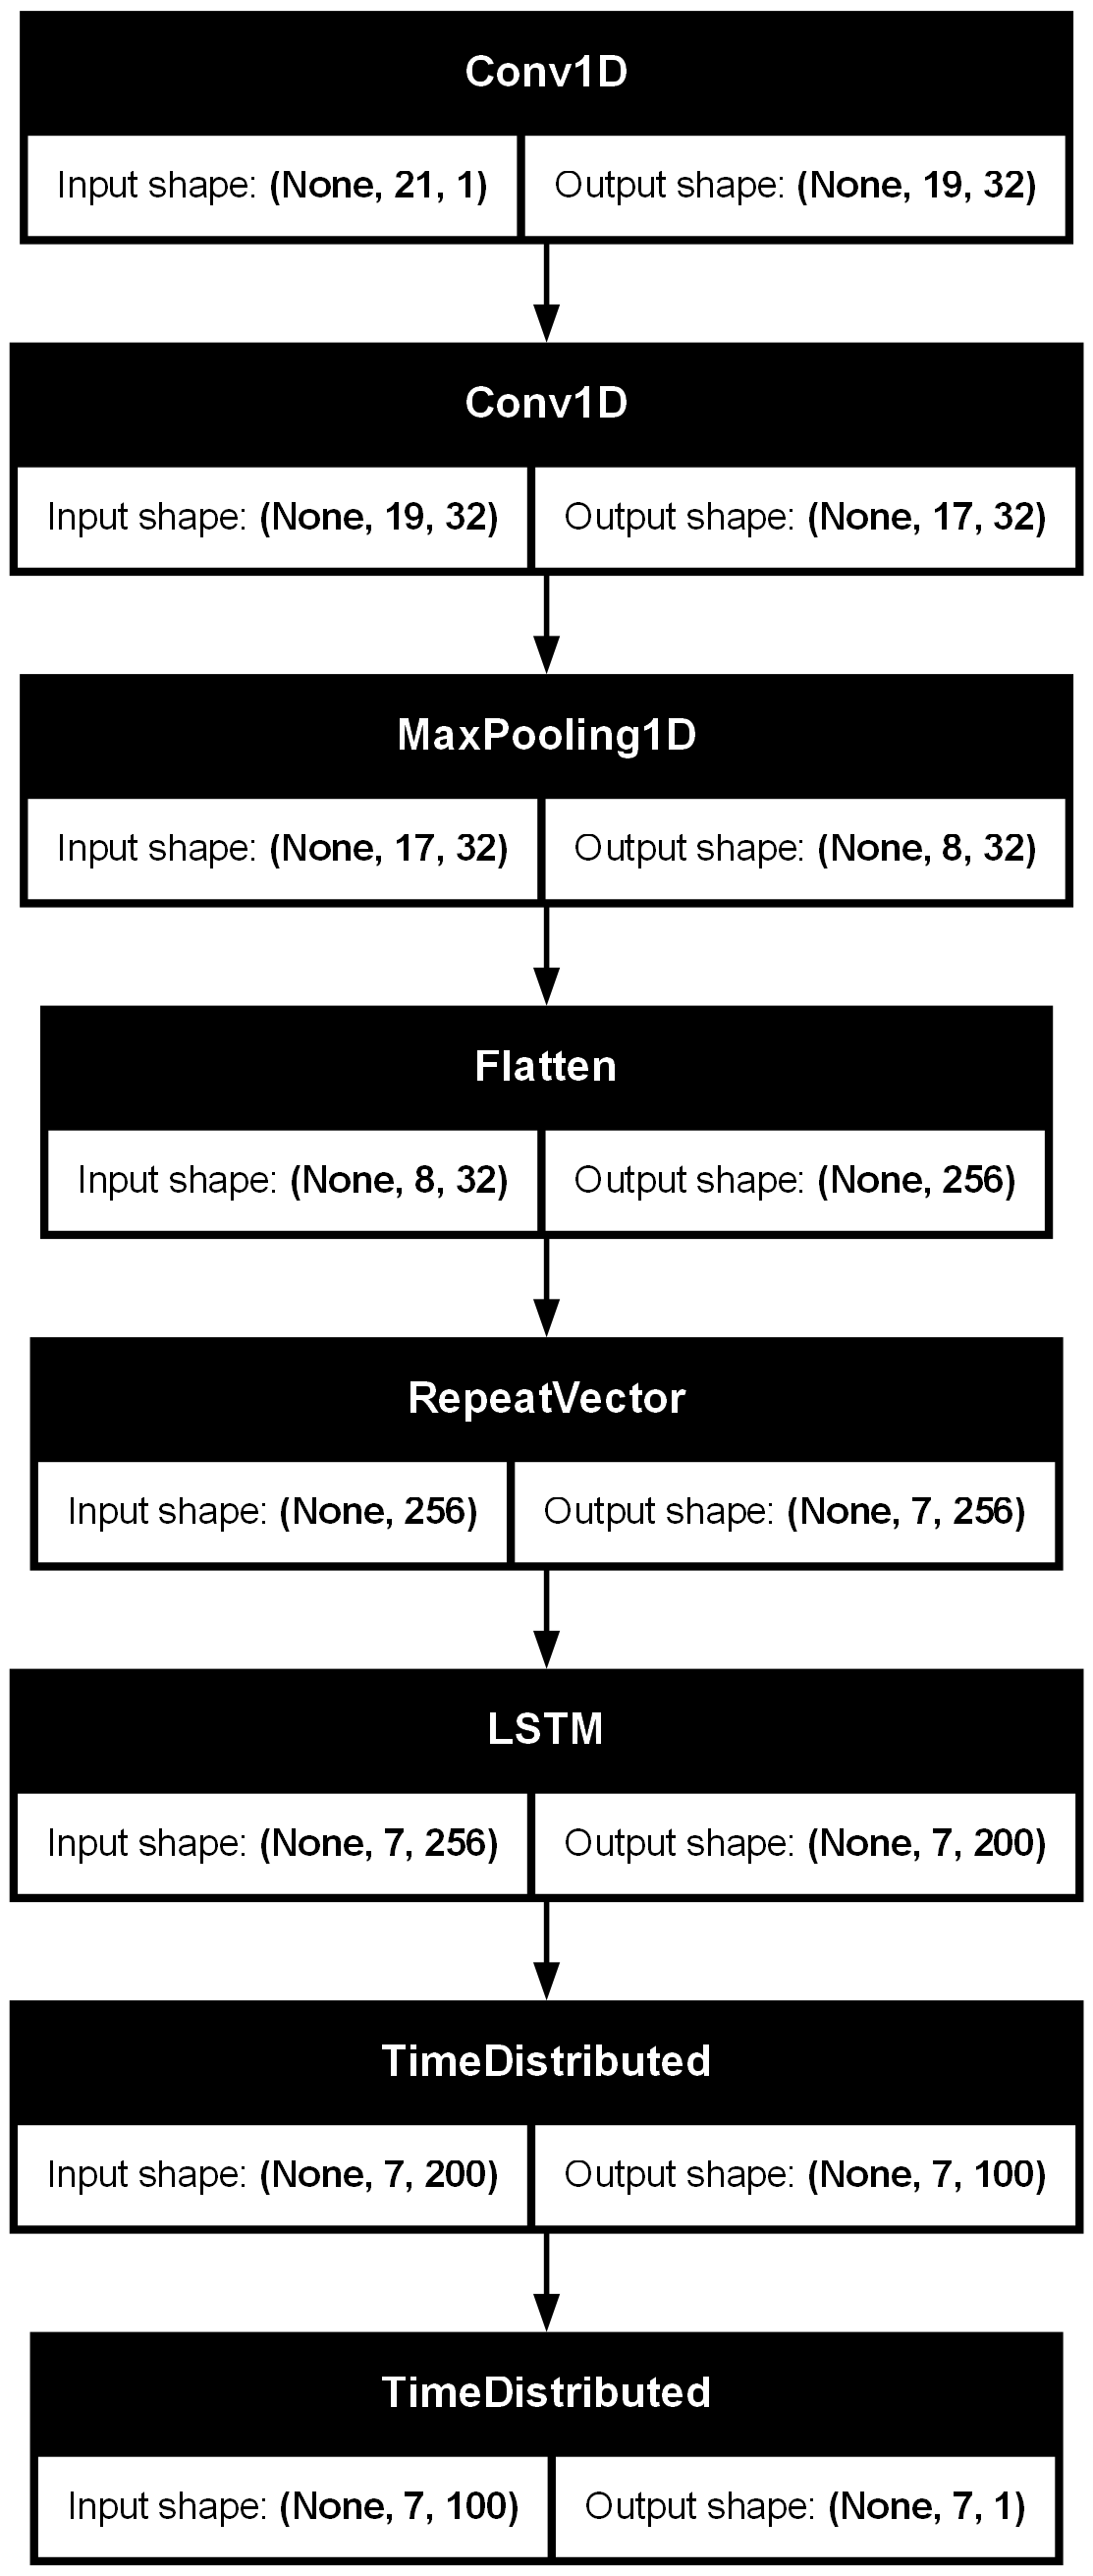

In [50]:
# Image('model_CNN-LSTM_univariate_multistep_output.png')

from IPython.display import Image, display

model, history = build_model(train, n_input, n_output)
# 1. Generate the file
plot_model(model, to_file='model_architecture.png', show_shapes=True)

# 2. Display the file
display(Image(filename='model_architecture.png'))

# Compare actual and predicted values

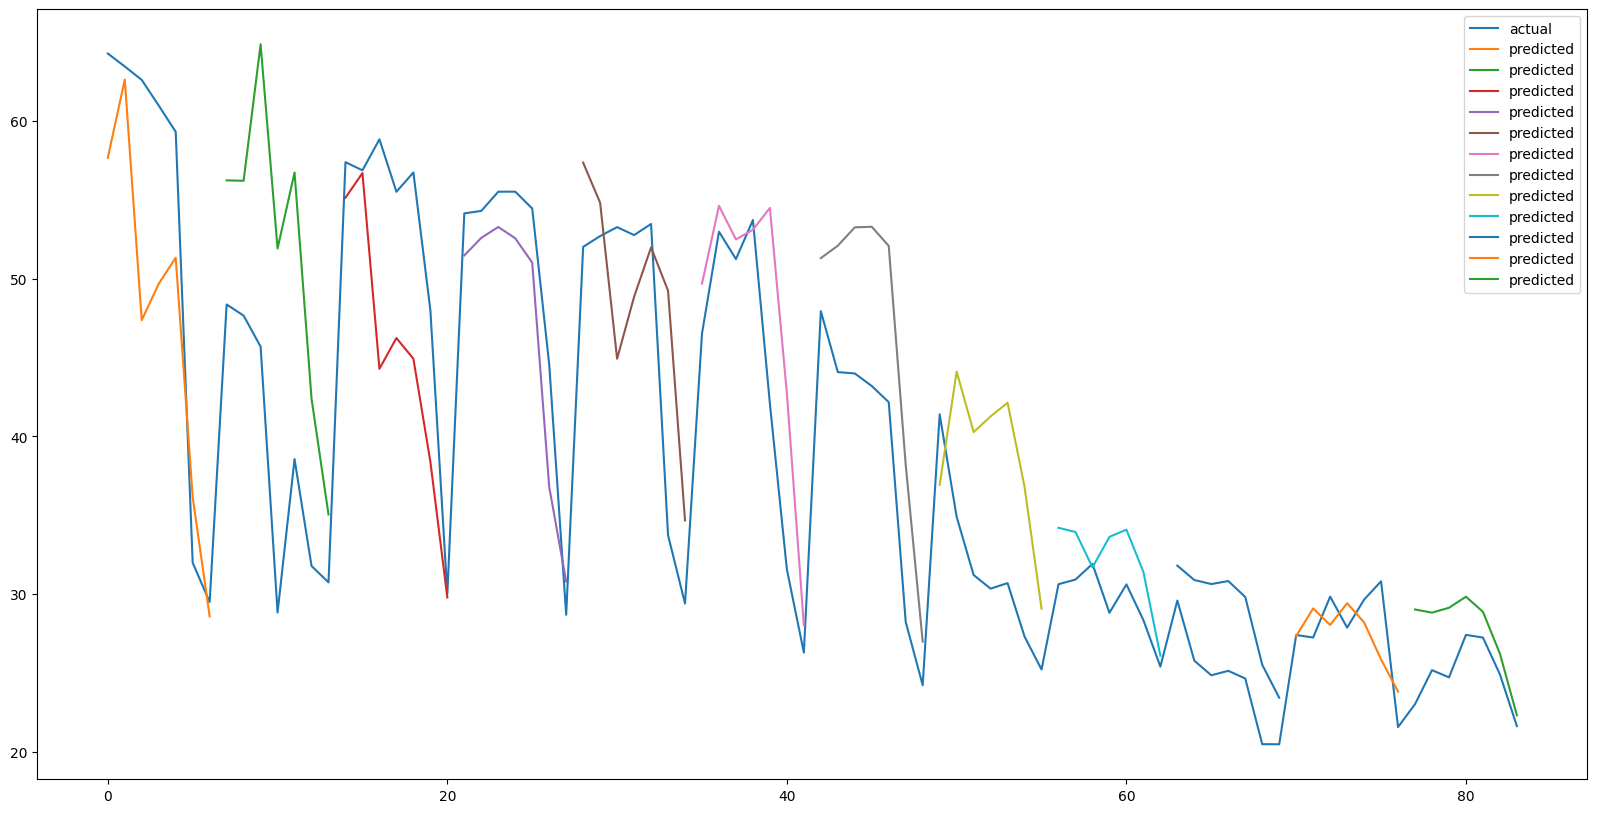

In [51]:
def plot_predictions(actual, predicted):
    fig = plt.figure(figsize=(20,10))
    plt.plot(actual, label='actual')
    for i in range(0, len(predicted), n_output):
        plt.plot(np.array(range(0+i, i+n_output)), predicted[0+i : i+n_output], label = 'predicted')
    plt.legend()
    plt.show()

# flatten actual and predictions data
actual = df.tail(nwp*n_output).iloc[: , 0].values
# actual_flat = actual.reshape(actual.shape[0]*actual.shape[1])
predictions_flat = predictions.reshape(predictions.shape[0]*predictions.shape[1])

# plot actual vs predicted
plot_predictions(actual, predictions_flat)


# RMSE for all sequences

In [52]:
def return_rmse(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print("The root mean squared error is {:.2f}.".format(rmse))

return_rmse(actual, predictions_flat)

The root mean squared error is 7.45.


In [53]:
time_end = time.time()
print("Notebook run time: {:.0f} seconds".format(time_end - time_start))

Notebook run time: 1782 seconds


## Performance metric for the baseline model (CNN-LSTM) and Models training loss and validation loss

Root Mean Squared Error (RMSE): 7.45 MW
Mean Absolute Error (MAE): 5.72 MW
R-squared Score (R2): 0.67


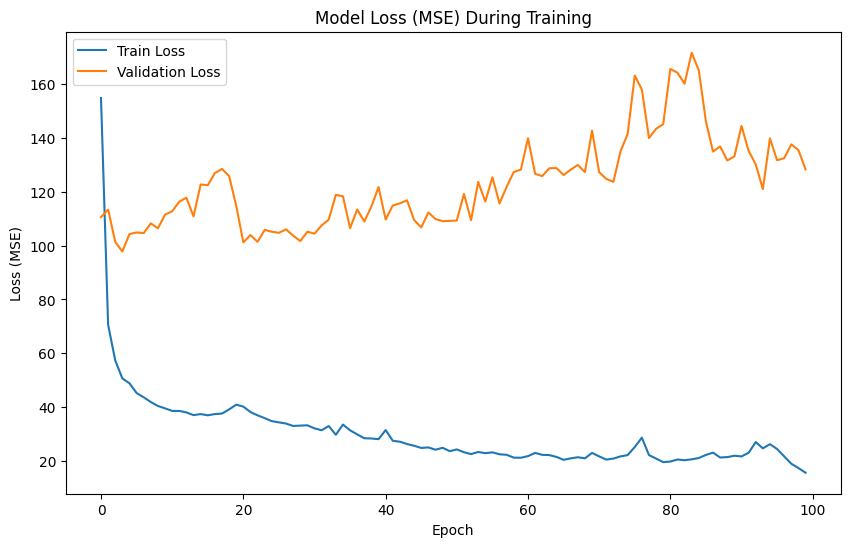

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def return_performance_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MW")
    print(f"Mean Absolute Error (MAE): {mae:.2f} MW")
    print(f"R-squared Score (R2): {r2:.2f}")
    
    return rmse, mae, r2
metrics = return_performance_metrics(actual, predictions_flat)

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (MSE) During Training')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()
